# Slang EDA Notebook

This notebook explores two datasets:

- `genz_slang_usage_2020_2025.csv`: post-level Gen Z slang usage from 2020-2025
- `2010_tweets_slang_analysis_ready.csv`: tweet-level 2010 slang usage

It is designed to help answer exploratory questions such as:

- Which platforms appear to originate the most slang?
- How do region and age shape slang origins in the Gen Z dataset?
- Is slang becoming more "efficient" by using fewer syllables or fewer words?
- How acronym-heavy is 2010 Twitter slang compared with the Gen Z dataset?
- What does the lifecycle of a slang term look like over time?

The focus here is interpretability. Each chart includes titles, labels, and annotations to make the main takeaway easy to read.

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.facecolor"] = "white"

ROOT = Path.cwd()
GENZ_PATH = ROOT / "genz_slang_usage_2020_2025.csv"
TWITTER_2010_SENTIMENT_PATH = ROOT / "2010_tweets_slang_with_sentiment.csv"
TWITTER_2010_PATH = (
    TWITTER_2010_SENTIMENT_PATH
    if TWITTER_2010_SENTIMENT_PATH.exists()
    else ROOT / "2010_tweets_slang_analysis_ready.csv"
)
TWITTER_2010_TERM_TABLE_PATH = ROOT / "tweets data prep" / "2010_terms_annotation_table.csv"

VOWEL_GROUP_RE = re.compile(r"[aeiouy]+", re.IGNORECASE)
TOKEN_RE = re.compile(r"[A-Za-z0-9]+")
ACRONYM_RE = re.compile(r"^[A-Z]{2,}$")


def count_syllables(text: str) -> int:
    text = (text or "").strip().lower()
    if not text:
        return 0

    tokens = re.findall(r"[a-z]+", text)
    if not tokens:
        return 0

    total = 0
    for token in tokens:
        groups = VOWEL_GROUP_RE.findall(token)
        syllables = len(groups)
        if token.endswith("e") and not token.endswith(("le", "ye")) and syllables > 1:
            syllables -= 1
        total += max(1, syllables)
    return total


def is_acronym(text: str) -> bool:
    value = (text or "").strip()
    return bool(ACRONYM_RE.fullmatch(value))


def bucket_syllables(value: int) -> str:
    if value <= 1:
        return "1"
    if value == 2:
        return "2"
    return "3+"


def add_term_features(df: pd.DataFrame, term_col: str) -> pd.DataFrame:
    enriched = df.copy()
    enriched["normalized_term"] = enriched[term_col].astype(str).str.strip().str.lower()
    enriched["char_count"] = enriched[term_col].astype(str).str.len()
    enriched["token_count"] = enriched[term_col].astype(str).apply(lambda value: len(TOKEN_RE.findall(value)))
    enriched["syllable_count"] = enriched[term_col].astype(str).apply(count_syllables)
    enriched["syllable_bucket"] = enriched["syllable_count"].apply(bucket_syllables)
    enriched["is_acronym"] = enriched[term_col].astype(str).apply(is_acronym)
    enriched["is_multiword"] = enriched["token_count"] > 1
    return enriched


genz = pd.read_csv(GENZ_PATH, parse_dates=["timestamp"])
twitter_2010 = pd.read_csv(TWITTER_2010_PATH, parse_dates=["date"])
term_table_2010 = pd.read_csv(TWITTER_2010_TERM_TABLE_PATH)

genz = add_term_features(genz, "slang_term")
genz["year"] = genz["timestamp"].dt.year
genz["month"] = genz["timestamp"].dt.to_period("M").astype(str)

twitter_2010 = add_term_features(twitter_2010, "word")
twitter_2010["year"] = twitter_2010["date"].dt.year
twitter_2010["month"] = twitter_2010["date"].dt.to_period("M").astype(str)
twitter_2010 = twitter_2010.merge(
    term_table_2010[["word", "origin_platform", "origin_platform_confidence", "tweet_count"]],
    on="word",
    how="left",
)

print(f"Gen Z rows: {len(genz):,}")
print(f"2010 Twitter rows: {len(twitter_2010):,}")
print(f"2010 source file: {TWITTER_2010_PATH.name}")

## 1. Dataset Snapshot

Before plotting, it helps to understand what each dataset can and cannot support.

- The Gen Z dataset is richer at the post level: it includes `origin_platform`, `usage_platform`, `region`, `user_age_group`, `sentiment`, and lifecycle fields.
- The 2010 dataset is leaner at the tweet level, but joining the term table adds `origin_platform` so it can still support comparison work.
- Only the Gen Z dataset supports region and age analyses directly.

In [ ]:
summary = pd.DataFrame(
    [
        {
            "dataset": "Gen Z 2020-2025",
            "rows": len(genz),
            "unique_terms": genz["normalized_term"].nunique(),
            "time_range": f"{genz['timestamp'].min().date()} to {genz['timestamp'].max().date()}",
            "platform_fields": "origin_platform + usage_platform",
            "demographic_fields": "region + user_age_group",
        },
        {
            "dataset": "Twitter 2010",
            "rows": len(twitter_2010),
            "unique_terms": twitter_2010["normalized_term"].nunique(),
            "time_range": f"{twitter_2010['date'].min().date()} to {twitter_2010['date'].max().date()}",
            "platform_fields": "origin_platform after join",
            "demographic_fields": "not available",
        },
    ]
)

summary

,dataset,rows,unique_terms,time_range,platform_fields,demographic_fields
0,Gen Z 2020-2025,535396,46,2020-01-01 to 2025-12-31,origin_platform + usage_platform,region + user_age_group
1,Twitter 2010,36005,152,2010-01-01 to 2011-01-06,origin_platform after join,not available


## 2. Which Platforms Originate the Most Slang Over Time?

This is one of the strongest questions your data can answer.

The chart below uses the Gen Z dataset because it contains both year and origin-platform information at scale. A stacked area chart is useful here because it shows both overall slang volume and how platform composition changes over time.

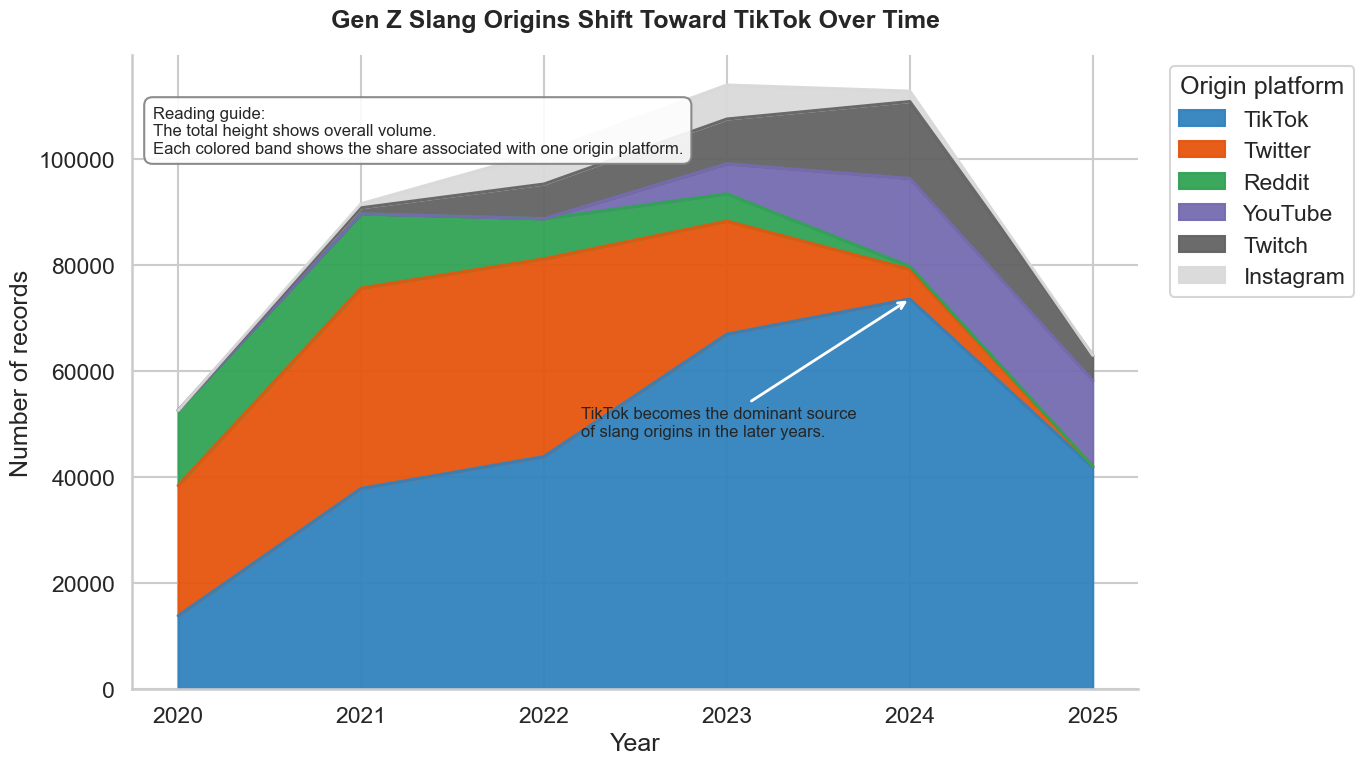

In [ ]:
origin_by_year = (
    genz.groupby(["year", "origin_platform"])
    .size()
    .unstack(fill_value=0)
)
origin_by_year = origin_by_year[origin_by_year.sum().sort_values(ascending=False).index]

ax = origin_by_year.plot.area(colormap="tab20c", alpha=0.95)
ax.set_title("Gen Z Slang Origins Shift Toward TikTok Over Time", pad=20)
ax.set_xlabel("Year")
ax.set_ylabel("Number of records")
ax.legend(title="Origin platform", bbox_to_anchor=(1.02, 1), loc="upper left")

ax.text(
    0.02,
    0.92,
    "Reading guide:\nThe total height shows overall volume.\nEach colored band shows the share associated with one origin platform.",
    transform=ax.transAxes,
    fontsize=12,
    va="top",
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9),
)

ax.annotate(
    "TikTok becomes the dominant source\nof slang origins in the later years.",
    xy=(2024, origin_by_year.loc[2024, "TikTok"]),
    xytext=(2022.2, origin_by_year.to_numpy().max() * 0.65),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=12,
)

plt.tight_layout()
plt.show()

### From Origin to Spread: Platform-to-Platform Flow

The area chart shows which platforms appear to *originate* slang over time. The Sankey below adds a second lens: where slang seems to start versus where it actually gets used.

This is especially useful if you want to argue that some platforms act more like incubators, while others behave more like amplifiers or redistribution channels. Thicker flows indicate stronger platform-to-platform pathways.

In [ ]:
platform_flow = (
    genz.groupby(["origin_platform", "usage_platform"])
    .size()
    .reset_index(name="value")
    .sort_values("value", ascending=False)
)

origins = sorted(platform_flow["origin_platform"].unique())
uses = sorted(platform_flow["usage_platform"].unique())

origin_labels = [f"Origin: {label}" for label in origins]
usage_labels = [f"Usage: {label}" for label in uses]
all_labels = origin_labels + usage_labels

origin_index = {label: i for i, label in enumerate(origins)}
usage_index = {label: i + len(origins) for i, label in enumerate(uses)}

source = platform_flow["origin_platform"].map(origin_index).tolist()
target = platform_flow["usage_platform"].map(usage_index).tolist()
value = platform_flow["value"].tolist()

origin_color_map = {
    "TikTok": "rgba(255, 99, 132, 0.8)",
    "Twitter": "rgba(54, 162, 235, 0.8)",
    "Reddit": "rgba(255, 159, 64, 0.8)",
    "YouTube": "rgba(220, 53, 69, 0.8)",
    "Twitch": "rgba(153, 102, 255, 0.8)",
    "Instagram": "rgba(255, 205, 86, 0.8)",
    "Discord": "rgba(99, 102, 241, 0.8)",
}

node_colors = [origin_color_map.get(label, "rgba(160,160,160,0.8)") for label in origins] + ["rgba(190,190,190,0.8)" for _ in uses]
link_colors = [origin_color_map.get(label, "rgba(160,160,160,0.35)").replace("0.8", "0.35") for label in platform_flow["origin_platform"]]

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=22,
                thickness=18,
                line=dict(color="rgba(80,80,80,0.4)", width=0.6),
                label=all_labels,
                color=node_colors,
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=link_colors,
                customdata=platform_flow[["origin_platform", "usage_platform"]].to_numpy(),
                hovertemplate="Origin: %{customdata[0]}<br>Usage: %{customdata[1]}<br>Records: %{value:,}<extra></extra>",
            ),
        )
    ]
)

fig.update_layout(
    title=dict(
        text="How Gen Z Slang Flows From Origin Platforms to Usage Platforms",
        x=0.5,
        xanchor="center",
    ),
    font=dict(size=13),
    height=720,
    margin=dict(l=40, r=40, t=80, b=90),
    annotations=[
        dict(
            text="Reading guide: left-side nodes are origin platforms, right-side nodes are usage platforms, and thicker bands indicate stronger platform-to-platform flows.",
            x=0.5,
            y=-0.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=12),
            align="center",
        )
    ],
)

fig.show()

## 3. Region and Age Patterns in Platform Origins

This section helps answer two related questions:

- Do different regions lean on different slang-origin ecosystems?
- Do different age groups appear to pick up slang from different platforms?

To make the comparison fair, the heatmaps below are row-normalized. That means each row sums to 100%, so darker cells represent stronger relative platform preference rather than simply bigger population size.

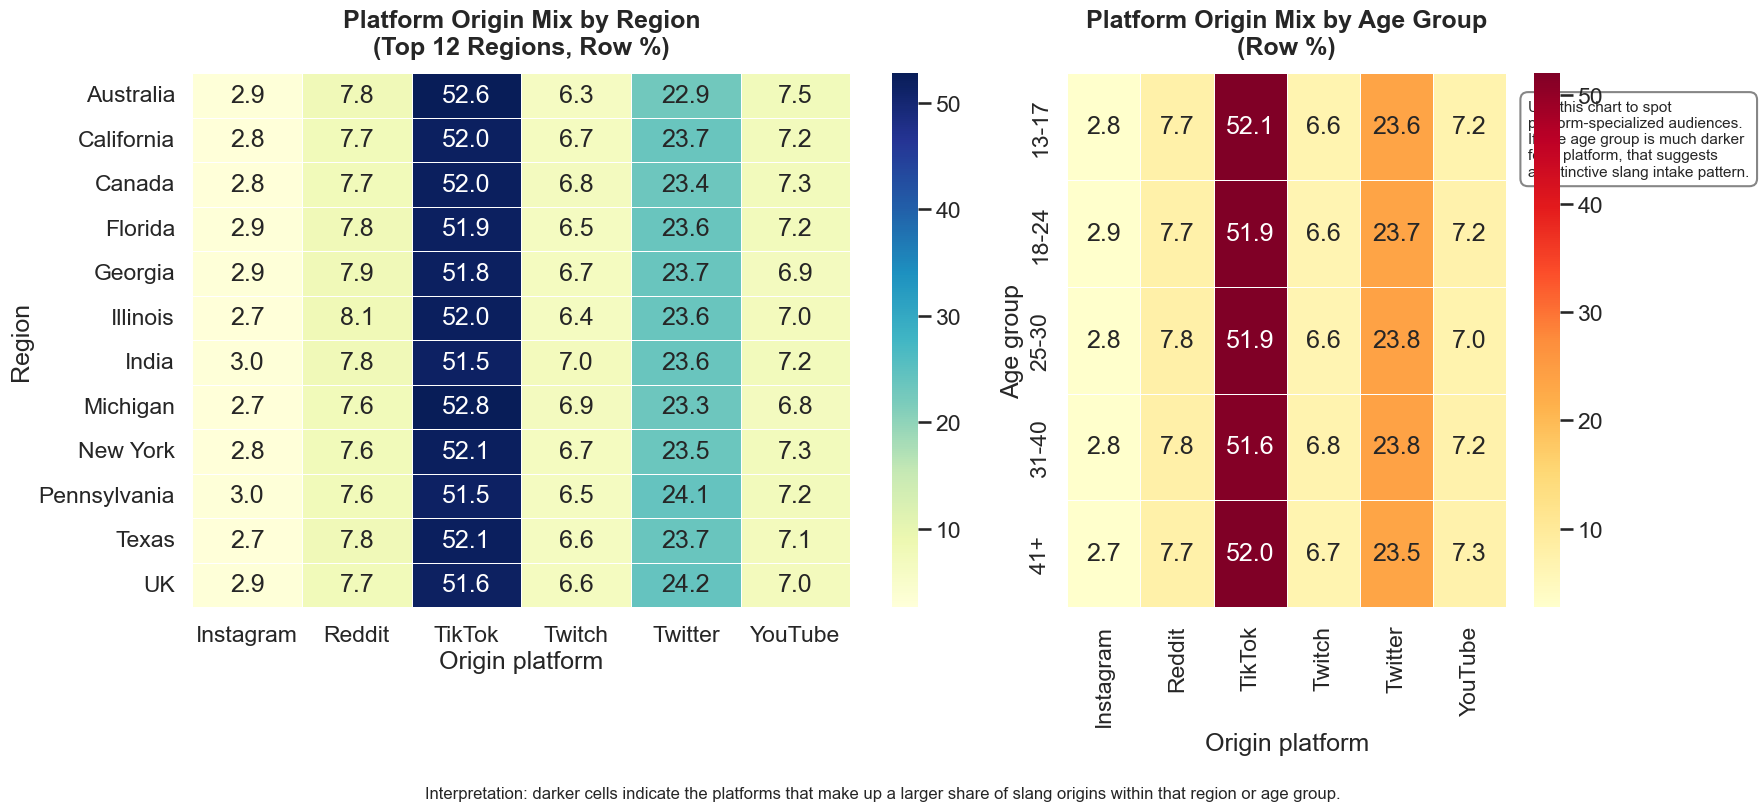

In [ ]:
top_regions = genz["region"].value_counts().head(12).index

region_platform = pd.crosstab(
    genz.loc[genz["region"].isin(top_regions), "region"],
    genz.loc[genz["region"].isin(top_regions), "origin_platform"],
    normalize="index",
) * 100

age_platform = pd.crosstab(
    genz["user_age_group"],
    genz["origin_platform"],
    normalize="index",
) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.5, 1]})

sns.heatmap(region_platform, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=0.5, ax=axes[0])
axes[0].set_title("Platform Origin Mix by Region\n(Top 12 Regions, Row %)", pad=14)
axes[0].set_xlabel("Origin platform")
axes[0].set_ylabel("Region")

sns.heatmap(age_platform, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.5, ax=axes[1])
axes[1].set_title("Platform Origin Mix by Age Group\n(Row %)", pad=14)
axes[1].set_xlabel("Origin platform")
axes[1].set_ylabel("Age group")

fig.text(
    0.5,
    -0.02,
    "Interpretation: darker cells indicate the platforms that make up a larger share of slang origins within that region or age group.",
    ha="center",
    fontsize=12,
)

axes[1].text(
    1.05,
    0.95,
    "Use this chart to spot\nplatform-specialized audiences.\nIf one age group is much darker\nfor a platform, that suggests\na distinctive slang intake pattern.",
    transform=axes[1].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.95),
)

plt.tight_layout()
plt.show()

## 4. Is Gen Z Slang Becoming More "Efficient"?

Efficiency can mean several things, so this notebook treats it as a combination of:

- fewer syllables per term
- fewer multiword phrases
- more compressed forms such as acronyms

The first chart tracks average syllables and the share of multiword terms by year in the Gen Z dataset. The second compares acronym prevalence across the two datasets.

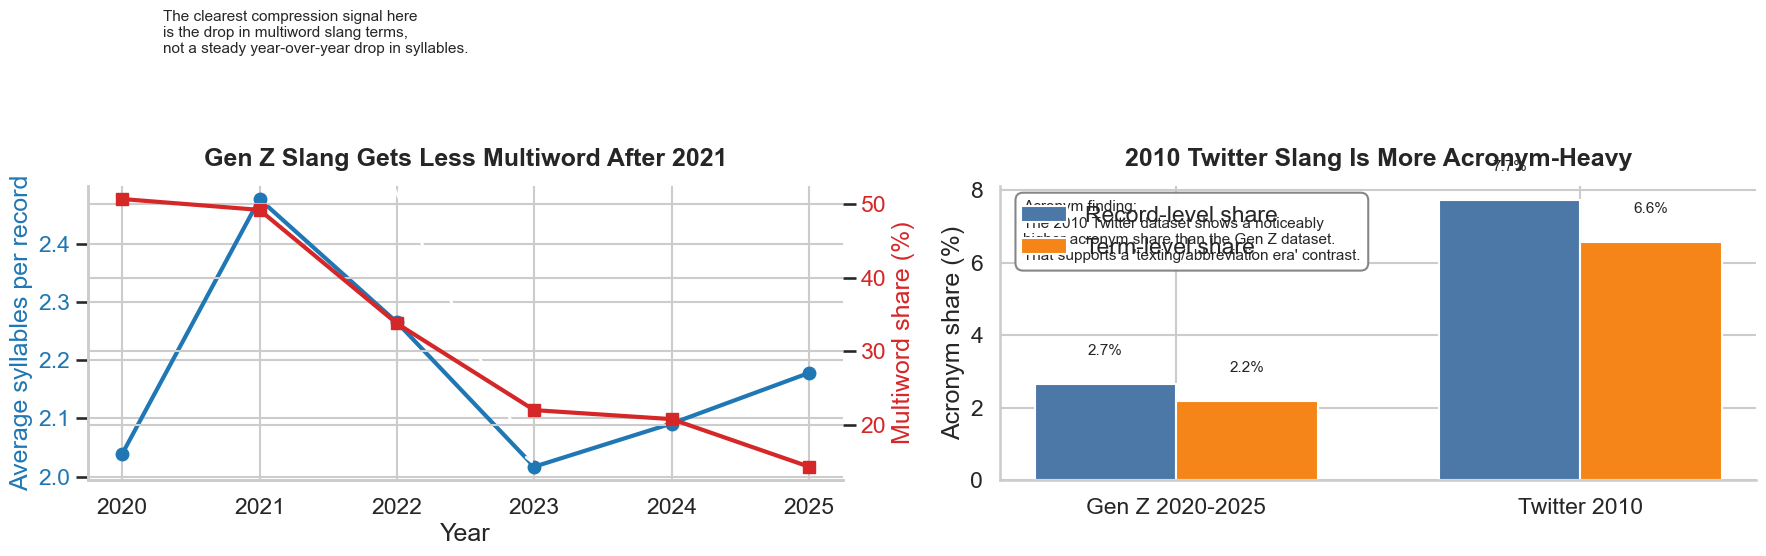

In [ ]:
efficiency_year = (
    genz.groupby("year")
    .agg(
        avg_syllables=("syllable_count", "mean"),
        multiword_share=("is_multiword", "mean"),
    )
    .reset_index()
)

acronym_compare = pd.DataFrame(
    {
        "dataset": ["Gen Z 2020-2025", "Twitter 2010"],
        "record_level_acronym_share": [genz["is_acronym"].mean(), twitter_2010["is_acronym"].mean()],
        "term_level_acronym_share": [
            genz.drop_duplicates("normalized_term")["is_acronym"].mean(),
            twitter_2010.drop_duplicates("normalized_term")["is_acronym"].mean(),
        ],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax1 = axes[0]
ax1.plot(efficiency_year["year"], efficiency_year["avg_syllables"], marker="o", lw=3, color="#1f77b4", label="Average syllables")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average syllables per record", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_title("Gen Z Slang Gets Less Multiword After 2021", pad=14)

ax1b = ax1.twinx()
ax1b.plot(efficiency_year["year"], efficiency_year["multiword_share"] * 100, marker="s", lw=3, color="#d62728", label="Multiword share")
ax1b.set_ylabel("Multiword share (%)", color="#d62728")
ax1b.tick_params(axis="y", labelcolor="#d62728")

ax1.annotate(
    "The clearest compression signal here\nis the drop in multiword slang terms,\nnot a steady year-over-year drop in syllables.",
    xy=(2023, efficiency_year.loc[efficiency_year['year'] == 2023, 'avg_syllables'].iloc[0]),
    xytext=(2020.3, efficiency_year['avg_syllables'].max() + 0.25),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=11,
)

ax2 = axes[1]
bar_positions = np.arange(len(acronym_compare))
width = 0.35
ax2.bar(bar_positions - width / 2, acronym_compare["record_level_acronym_share"] * 100, width=width, label="Record-level share", color="#4c78a8")
ax2.bar(bar_positions + width / 2, acronym_compare["term_level_acronym_share"] * 100, width=width, label="Term-level share", color="#f58518")
ax2.set_xticks(bar_positions)
ax2.set_xticklabels(acronym_compare["dataset"])
ax2.set_ylabel("Acronym share (%)")
ax2.set_title("2010 Twitter Slang Is More Acronym-Heavy", pad=14)
ax2.legend(frameon=False)

for i, row in acronym_compare.iterrows():
    ax2.text(i - width / 2, row["record_level_acronym_share"] * 100 + 0.8, f"{row['record_level_acronym_share'] * 100:.1f}%", ha="center", fontsize=11)
    ax2.text(i + width / 2, row["term_level_acronym_share"] * 100 + 0.8, f"{row['term_level_acronym_share'] * 100:.1f}%", ha="center", fontsize=11)

ax2.text(
    0.03,
    0.95,
    "Acronym finding:\nThe 2010 Twitter dataset shows a noticeably\nhigher acronym share than the Gen Z dataset.\nThat supports a 'texting/abbreviation era' contrast.",
    transform=ax2.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.95),
)

plt.tight_layout()
plt.show()

## 5. What Does a Slang Lifecycle Look Like?

The Gen Z dataset contains enough time depth to explore lifecycle patterns. One good exploratory move is to normalize each term's monthly usage so that all terms can be compared on the same scale.

That lets you compare shape rather than raw popularity. A term with a huge audience and a niche term can still be compared if both are scaled from 0 to 1.

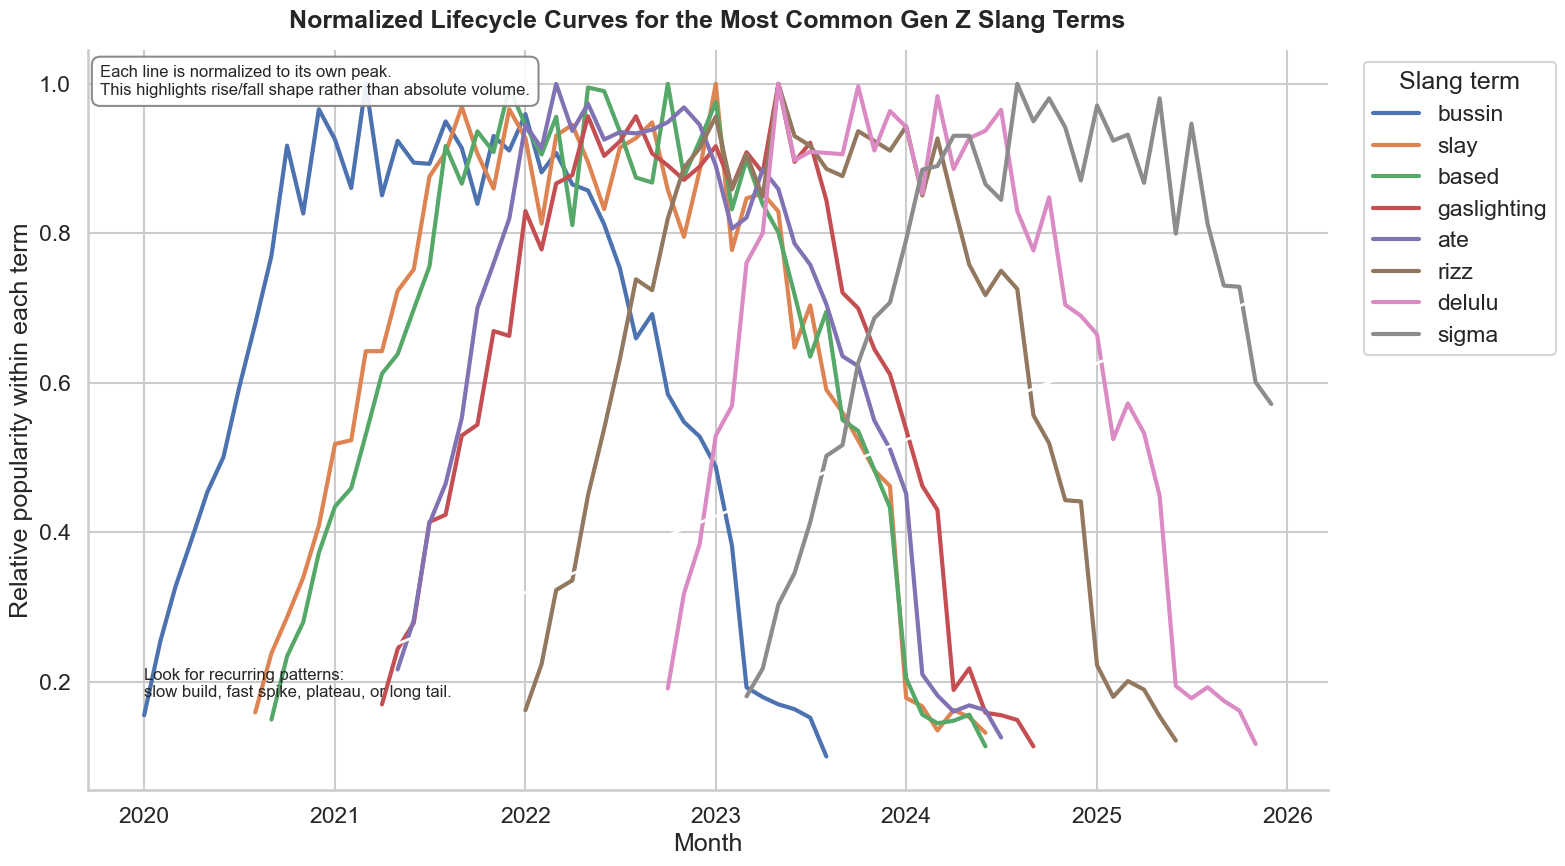

In [ ]:
top_terms = genz["slang_term"].value_counts().head(8).index
trajectory = (
    genz.loc[genz["slang_term"].isin(top_terms)]
    .groupby(["month", "slang_term"])
    .size()
    .reset_index(name="posts")
)

trajectory["normalized_posts"] = trajectory.groupby("slang_term")["posts"].transform(lambda s: s / s.max())
trajectory["month"] = pd.to_datetime(trajectory["month"])

plt.figure(figsize=(16, 9))
sns.lineplot(data=trajectory, x="month", y="normalized_posts", hue="slang_term", linewidth=3)
plt.title("Normalized Lifecycle Curves for the Most Common Gen Z Slang Terms", pad=16)
plt.xlabel("Month")
plt.ylabel("Relative popularity within each term")
plt.legend(title="Slang term", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.text(
    0.01,
    0.98,
    "Each line is normalized to its own peak.\nThis highlights rise/fall shape rather than absolute volume.",
    transform=plt.gca().transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9),
)

plt.annotate(
    "Look for recurring patterns:\nslow build, fast spike, plateau, or long tail.",
    xy=(trajectory['month'].max(), 0.72),
    xytext=(trajectory['month'].min(), 0.18),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=12,
)

plt.tight_layout()
plt.show()

## 6. Cross-Era Comparison: Category Mix and Sentiment

Exact term overlap between your 2010 and Gen Z term lists is currently zero, so the more robust comparison is structural rather than lexical.

Two strong structural comparisons are:

- the category composition of each dataset
- the overall sentiment distribution in each era
- the way sentiment is distributed within categories

The 2010 sentiment in this notebook comes from VADER applied to tweet text, while the Gen Z dataset already includes sentiment labels and scores. That makes this comparison useful for exploration, but it is still worth treating it as approximate rather than definitive.

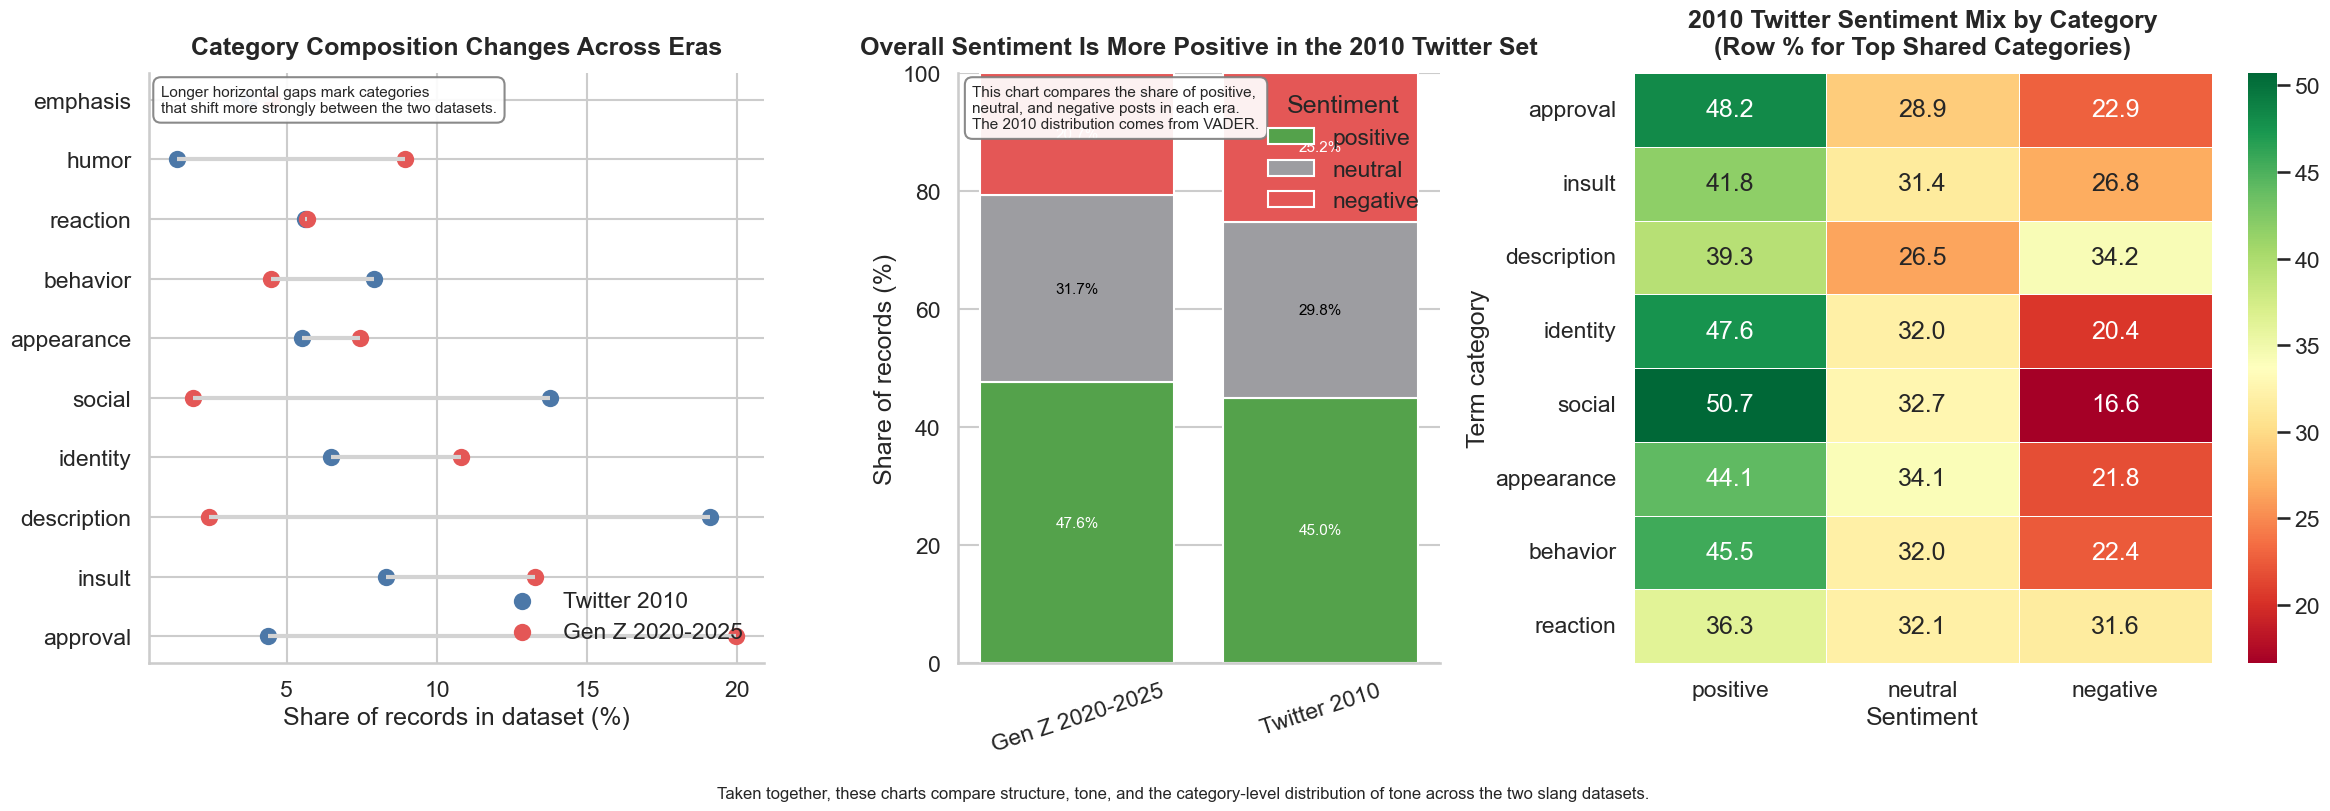

In [ ]:
genz_category = genz["term_category"].value_counts(normalize=True).rename("genz_share")
twitter_category = twitter_2010["term_category"].value_counts(normalize=True).rename("twitter_share")
category_compare = pd.concat([genz_category, twitter_category], axis=1).fillna(0)
category_compare["avg_share"] = category_compare.mean(axis=1)
category_compare = category_compare.sort_values("avg_share", ascending=False).head(10).drop(columns="avg_share")

genz_sentiment_col = "sentiment_label" if "sentiment_label" in genz.columns else "sentiment"
twitter_sentiment_col = "sentiment_label"
sentiment_order = ["positive", "neutral", "negative"]

overall_sentiment = pd.DataFrame(
    {
        "dataset": ["Gen Z 2020-2025", "Twitter 2010"],
        "positive": [
            (genz[genz_sentiment_col] == "positive").mean() * 100,
            (twitter_2010[twitter_sentiment_col] == "positive").mean() * 100,
        ],
        "neutral": [
            (genz[genz_sentiment_col] == "neutral").mean() * 100,
            (twitter_2010[twitter_sentiment_col] == "neutral").mean() * 100,
        ],
        "negative": [
            (genz[genz_sentiment_col] == "negative").mean() * 100,
            (twitter_2010[twitter_sentiment_col] == "negative").mean() * 100,
        ],
    }
)

genz_sentiment_category = (
    genz.groupby(["term_category", genz_sentiment_col])
    .size()
    .reset_index(name="posts")
    .rename(columns={genz_sentiment_col: "sentiment_label"})
)
twitter_sentiment_category = (
    twitter_2010.groupby(["term_category", twitter_sentiment_col])
    .size()
    .reset_index(name="tweets")
    .rename(columns={twitter_sentiment_col: "sentiment_label"})
)

top_sentiment_categories = category_compare.index[:8]
genz_sentiment_category = genz_sentiment_category[genz_sentiment_category["term_category"].isin(top_sentiment_categories)]
twitter_sentiment_category = twitter_sentiment_category[twitter_sentiment_category["term_category"].isin(top_sentiment_categories)]

fig, axes = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={"width_ratios": [1.15, 0.9, 1.35]})

ax1 = axes[0]
y_positions = np.arange(len(category_compare))
ax1.hlines(y=y_positions, xmin=category_compare["twitter_share"] * 100, xmax=category_compare["genz_share"] * 100, color="lightgray", lw=3)
ax1.scatter(category_compare["twitter_share"] * 100, y_positions, color="#4c78a8", s=120, label="Twitter 2010")
ax1.scatter(category_compare["genz_share"] * 100, y_positions, color="#e45756", s=120, label="Gen Z 2020-2025")
ax1.set_yticks(y_positions)
ax1.set_yticklabels(category_compare.index)
ax1.set_xlabel("Share of records in dataset (%)")
ax1.set_title("Category Composition Changes Across Eras", pad=14)
ax1.legend(frameon=False, loc="lower right")

ax1.text(
    0.02,
    0.98,
    "Longer horizontal gaps mark categories\nthat shift more strongly between the two datasets.",
    transform=ax1.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.92),
)

ax2 = axes[1]
bottom = np.zeros(len(overall_sentiment))
palette = {"positive": "#54a24b", "neutral": "#9d9da1", "negative": "#e45756"}
for label in sentiment_order:
    values = overall_sentiment[label].values
    ax2.bar(overall_sentiment["dataset"], values, bottom=bottom, color=palette[label], label=label)
    for i, value in enumerate(values):
        ax2.text(i, bottom[i] + value / 2, f"{value:.1f}%", ha="center", va="center", fontsize=11, color="white" if label != "neutral" else "black")
    bottom += values
ax2.set_ylim(0, 100)
ax2.set_ylabel("Share of records (%)")
ax2.set_title("Overall Sentiment Is More Positive in the 2010 Twitter Set", pad=14)
ax2.legend(title="Sentiment", frameon=False, loc="upper right")
ax2.tick_params(axis="x", rotation=18)

ax2.text(
    0.03,
    0.98,
    "This chart compares the share of positive,\nneutral, and negative posts in each era.\nThe 2010 distribution comes from VADER.",
    transform=ax2.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.92),
)

ax3 = axes[2]
twitter_heatmap = pd.crosstab(
    twitter_sentiment_category["term_category"],
    twitter_sentiment_category["sentiment_label"],
    values=twitter_sentiment_category["tweets"],
    aggfunc="sum",
    normalize="index",
).reindex(index=top_sentiment_categories, columns=sentiment_order).fillna(0) * 100
sns.heatmap(twitter_heatmap, cmap="RdYlGn", annot=True, fmt=".1f", linewidths=0.5, ax=ax3)
ax3.set_title("2010 Twitter Sentiment Mix by Category\n(Row % for Top Shared Categories)", pad=14)
ax3.set_xlabel("Sentiment")
ax3.set_ylabel("Term category")

fig.text(
    0.5,
    -0.02,
    "Taken together, these charts compare structure, tone, and the category-level distribution of tone across the two slang datasets.",
    ha="center",
    fontsize=12,
)

plt.tight_layout()
plt.show()

## 7. Side-by-Side Category-Level Sentiment Comparison

The previous section compares overall tone and the 2010 category-level pattern. This final comparison goes one step further by putting both datasets on the same category-by-sentiment grid.

The left heatmap shows the Gen Z distribution, the middle heatmap shows the 2010 Twitter distribution, and the right heatmap shows the difference in percentage points. Positive values mean a category is more associated with that sentiment in Gen Z; negative values mean it is more associated with that sentiment in 2010 Twitter.

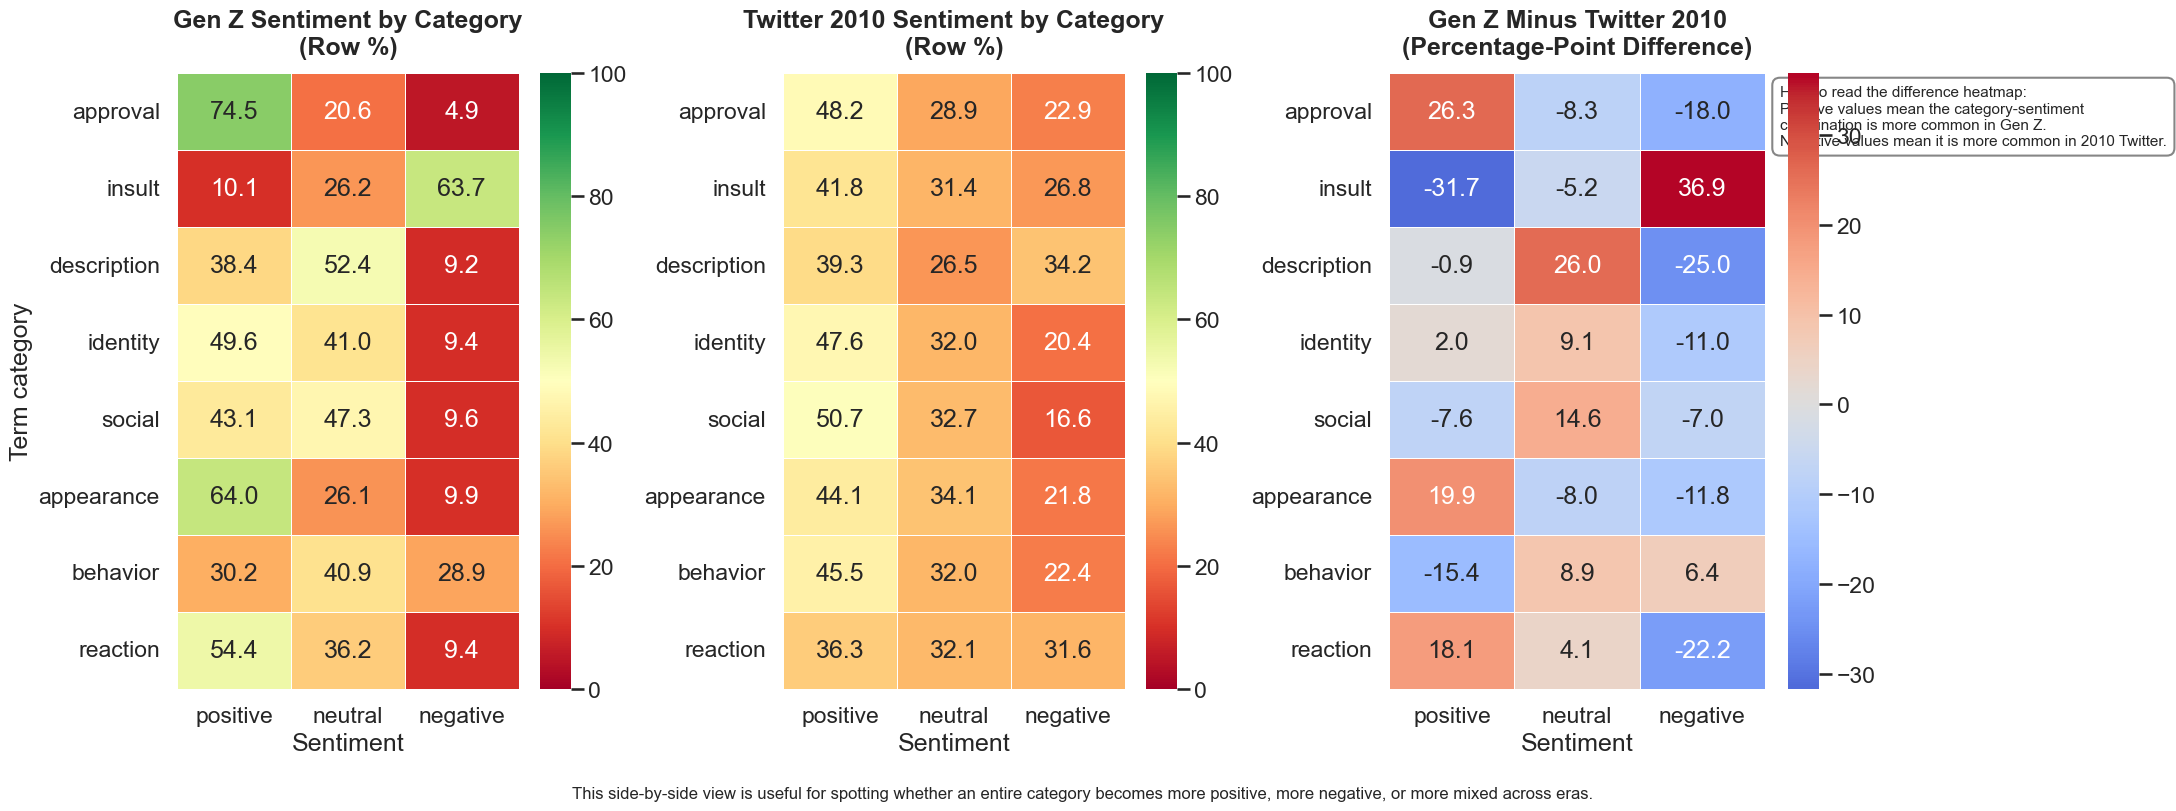

In [ ]:
genz_heatmap = pd.crosstab(
    genz_sentiment_category["term_category"],
    genz_sentiment_category["sentiment_label"],
    values=genz_sentiment_category["posts"],
    aggfunc="sum",
    normalize="index",
).reindex(index=top_sentiment_categories, columns=sentiment_order).fillna(0) * 100

twitter_heatmap = pd.crosstab(
    twitter_sentiment_category["term_category"],
    twitter_sentiment_category["sentiment_label"],
    values=twitter_sentiment_category["tweets"],
    aggfunc="sum",
    normalize="index",
).reindex(index=top_sentiment_categories, columns=sentiment_order).fillna(0) * 100

difference_heatmap = (genz_heatmap - twitter_heatmap).round(1)

fig, axes = plt.subplots(1, 3, figsize=(22, 8), gridspec_kw={"width_ratios": [1, 1, 1.1]})

sns.heatmap(genz_heatmap, cmap="RdYlGn", annot=True, fmt=".1f", linewidths=0.5, ax=axes[0], vmin=0, vmax=100)
axes[0].set_title("Gen Z Sentiment by Category\n(Row %)", pad=14)
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Term category")

sns.heatmap(twitter_heatmap, cmap="RdYlGn", annot=True, fmt=".1f", linewidths=0.5, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title("Twitter 2010 Sentiment by Category\n(Row %)", pad=14)
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("")

sns.heatmap(difference_heatmap, cmap="coolwarm", center=0, annot=True, fmt=".1f", linewidths=0.5, ax=axes[2])
axes[2].set_title("Gen Z Minus Twitter 2010\n(Percentage-Point Difference)", pad=14)
axes[2].set_xlabel("Sentiment")
axes[2].set_ylabel("")

axes[2].text(
    1.04,
    0.98,
    "How to read the difference heatmap:\nPositive values mean the category-sentiment\ncombination is more common in Gen Z.\nNegative values mean it is more common in 2010 Twitter.",
    transform=axes[2].transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.95),
)

fig.text(
    0.5,
    -0.02,
    "This side-by-side view is useful for spotting whether an entire category becomes more positive, more negative, or more mixed across eras.",
    ha="center",
    fontsize=12,
)

plt.tight_layout()
plt.show()

## 8. Suggested Next Steps

If you want to keep extending this notebook, the most promising additions are:

1. Build a `origin_platform -> usage_platform` Sankey diagram for the Gen Z dataset.
2. Create small multiples of term trajectories split by `origin_platform` or `term_category`.
3. Map region-level origin patterns if you decide to normalize or collapse the region field into a cleaner geography layer.
4. Add a timeline view of monthly sentiment shifts inside each dataset.
5. Turn the strongest 3-4 charts into polished final figures for your project report or presentation.

Important caveat: the Gen Z dataset appears highly structured, so it is safest to frame findings as patterns **within this dataset** rather than as definitive claims about all real-world slang behavior.